In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import scipy

from InSitu14CO import Propagator
import Functions_14CO as F

from tqdm import tqdm

from time import time

from scipy.interpolate import interp1d

from Firn_Model import Accumulation_Site

In [2]:
# setup pyplot formatting

axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '14' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

In [3]:
COS_partition = np.array(
    [#CO2         CO          CH4
    [0.686307104, 0.31125305, 0.002439846], # neutron
    [0.686307104, 0.31125305, 0.002439846], # neg muon
    [0.686307104, 0.31125305, 0.002439846], # fast muon
])

In [4]:
Prop_DC = Propagator()

In [5]:
C14CO_const = 1
# setup Accumulation Site data
Dome_C = Accumulation_Site(C14CO_const = C14CO_const)

#L = np.array([1, *np.arange(5e-4,1.4e-3+1e-9, 1e-4)])
L = np.array([1, 7e-4])
#L = np.array([1, 1e-4, 5e-4, 8e-4, 9e-4, 1e-3, 2e-3, 1e-2, 1e-1])
#L = [0.0007]
# caculate cosmogenic 14C in reservoirs w/ Leakage rates L
C14_grains, C14_leak_open, C14_leak_closed, C14_cumuleak_closed = Dome_C.Calc_14C_ice(L=L)

# calculate 14CO concentrations in open porosity, + concentration trapped into closed porosity
C14_open_gas, C14_closed_gas, C14_open_atm, C14_closed_atm, c_gases = Dome_C.Calc_profiles(C14_leak_open)

/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:215: RuntimeWarning: invalid value encountered in divide
  bubble_pres = self.dz*(np.cumsum(dscl*C*self.s)*(1+np.log(v_ice)) - np.cumsum(dscl*C*self.s*np.log(v_ice)))/(self.s_closed-self.s_closed[0])/self.s
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:350: RuntimeWarning: divide by zero encountered in log
  Lrate = -np.log(1-L)
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:352: RuntimeWarning: invalid value encountered in multiply
  Ctemp = np.exp(-(lambd+Lrate)*COS_age) * np.cumsum((COS_P).reshape((-1,3,1)) * np.exp((lambd+Lrate)*COS_age) * COS_dt, axis=0)
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:571: RuntimeWarning: divide by zero encountered in divide
  gram_to_ppm = 1e18*Site.R*Site.T / (6.022140857e23*Site.pressure*Site.s_open/Site.rho*np.exp(Site.M_air*Site.g*Site.z/(Site.R*Site.T))*1e-6)
/home/wcook/.local/lib/python3.10/site-package

0.24260711669921875
interpolating...


100%|█████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 11.37it/s]


integrating...
  Calculated open and closed profiles for gas 1 out of 1
1.9179904460906982


Let's start off by defining our dimensional grids.

$t$ - measurement time [1]; absolute, (single value?), indexes historical profiles ($\vec{\phi}$, $\vec{c}^{atm}$)

$t'$ - production time [~t]; relative to measurement, constant spacing, binned ($t'^+$ upper bound, $t'^-$ lower bound, $t'$ center, $dt'$ width)

$p$ - production depth [~z]; corresponds to age profile

$a$ - accumulation depth [~z]; corresponds to age profile

$s$ - sample depth [~s]; depth ranges of measurement, binned ($s^+$ upper bound, $s^-$ lower bound, $s$ center, $\Delta s$ width)

$l$ - reservoirs & leakage rates [~l]; can only be calculated at discrete values unless I think of something really clever

In [6]:
Dome_C.Acc*Dome_C.rho_ice

0.025479893788859998

In [7]:
np.mean(np.diff(Prop_DC.h_grid)/np.diff(Prop_DC.age_grid)/Dome_C.rho_ice)

np.float64(0.02758633420806933)

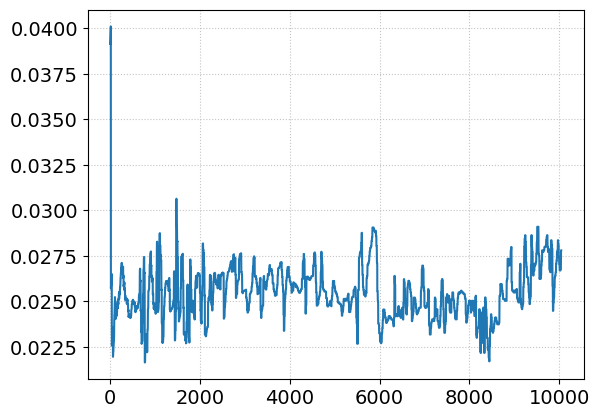

In [8]:
plt.plot(np.diff(Prop_DC.h_grid)/np.diff(Prop_DC.age_grid))

In [9]:
dt1 = 10
t1_bins = np.arange(0, Prop_DC.age_grid[-1], dt1)
t1_bins = t1_bins-t1_bins[-1]
t1 = (t1_bins[:-1]+t1_bins[1:])/2
t1.shape

(1004,)

In [10]:
#p = Dome_C.IceAge * Dome_C.Acc * Dome_C.rho_ice
p = Prop_DC.h_bins
p.shape

(256,)

In [11]:
f_factors = np.array([1., 0.06, 0.08])
P = f_factors @ np.array(Dome_C.COS_Production(p))
P.shape

(256,)

In [12]:
a_bins = Prop_DC.age_to_h(t1_bins-t1_bins[0])
a = (a_bins[:-1]+a_bins[1:])/2
da = np.diff(a_bins)
a.shape

(1004,)

In [13]:
L.shape

(2,)

In [14]:
lambd = Prop_DC.lambd
lambd

0.0001216

In [15]:
def smooth_diff(f):
    return np.concatenate(( [(f[1]-f[0])], (f[2:]-f[:-2])/2, [(f[-1]-f[-2])] ), axis=0)

In [16]:
h_bins = Prop_DC.age_to_h(t1_bins-t1_bins[0])
h = (h_bins[:-1]+h_bins[1:])/2
dh = np.diff(h_bins)

z_bins = Prop_DC.age_to_z(t1_bins-t1_bins[0])
z = (z_bins[:-1]+z_bins[1:])/2
dz = np.diff(z_bins)

age_bins = t1_bins-t1_bins[0]
age = (age_bins[:-1]+age_bins[1:])/2
dage = np.diff(age_bins)

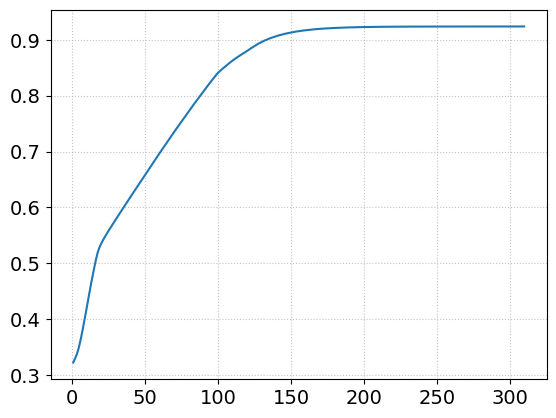

In [17]:
rho = dh/dz
plt.plot(z, rho)

In [18]:
#z = Dome_C.z
#dz = Dome_C.dz
#rho = Dome_C.rho
#rho_ice = Dome_C.rho_ice
#Acc = Dome_C.Acc * Dome_C.rho_ice

In [19]:
rho_ice = max(0.9165 - (Dome_C.T-273.15)*1.4438e-4 - (Dome_C.T-273.15)**2 * 1.5175e-7, max(rho)+1e-9) # Schwander et al.
rho_co = 0.833 # density at close off depth? idk

s = 1 - rho/rho_ice # porosity of ice by depth
s_closed = (0.37 * s * (s/(1-rho_co/rho_ice))**(-7.6)).clip(max=s) # closed porosity
s_open = s - s_closed # open porosity

teller_co = np.argmax(s_closed) # depth index of maximum closed porosity (close off depth??)

Assuming $p=At'$, corresponding to our production time grid:

$$\vec{c}^{\text{grains}}_{a,t} = \sum_{t'}(\vec{R}\cdot\hat{A}^{\text{grains}})_{t'}(\vec{P}\cdot\vec{f})_{a+At'}\vec{\phi}_{t'+t}$$

If we instead let $p$ have a different grid shape than $At'$,

$$\vec{c}^{\text{grains}}_{a,t} = \sum_{t',p} (\vec{R}\cdot\hat{A}^{\text{grains}})_{t'}\hat{\delta}_{p,a+At'}(\vec{P}\cdot\vec{f})_{p}\vec{\phi}_{t'+t}$$

$$\hat{A}^{\text{grains}}_{l,t} = (1-\vec{L})^{-t'} e^{\lambda t'} dt'$$

where $\hat{\delta}_{p,a+At'}$ acts as a linear interpolation from $p$ to $a+At'$

$\hat{H}$ - accumulation depth interpolation operator (interpolates production depths to h'(h,t))

$$H_i(h') = (\frac{h'-h_{i-1}}{h_i-h_{i-1}}).\text{clip}(0,1) - (\frac{h'-h_{i}}{h_{i+1}-h_{i}}).\text{clip}(0,1)$$

$h'(h,t)$ - depth at time $t$ of ice parcel w/ present accumulation depth $h$

$h_i$ - propagation depths (for $i$<0 or $i$>max, replace the terms with $h'\geq h_0$ and $h'>h_{\text{max}}$, respectively)

$\hat{S}$ - sample operator (averages over each sample depth range in accumulation depth)

$$S(s,h) = \frac{(s^+ - h^-).\text{clip}(0,\Delta h) - (s^- - h^-).\text{clip}(0,\Delta h)}{\sum_h (s^+ - h^-).\text{clip}(0,\Delta h) - (s^- - h^-).\text{clip}(0,\Delta h)}$$

$s$ - sample depth bins (+ upper bound, - lower bound)

$h$ - accumulation depth bins (- lower bound, $\Delta$ width)

In [20]:
def interp_mat(bins, grid): # interpolates between bin centers & grid
    # input arrays must have broadcastable shape
    # grid's primary index should be along axis -1
    grid_slope = ((bins-grid[...,:-1])/np.diff(grid,axis=-1)).clip(0,1) # slope from 0 to 1 as x passes from lower to upper bound
    return np.concatenate([1*(bins>=grid[...,:1])-grid_slope[...,:1], -np.diff(grid_slope, axis=-1), 0*grid_slope[...,-1:]-0*(bins>grid[...,-1:])], axis=-1)

In [21]:
A_grains = (1-L[:,None])**(-t1[None,:]) * np.exp(lambd*t1[None,:]) * dt1
#axis0 - leakage rate (l)
#axis1 - production time (t')
A_grains.shape

(2, 1004)

In [22]:
a_hist = Prop_DC.age_to_h(age[None,:] + t1[:,None]) - 10*(age[None,:]+t1[:,None] < 0)
delta_pahist = np.moveaxis(interp_mat(a_hist[:,:,None],p[None,None,:]), 0, -1)
#axis0 - accumulation depth (a)
#axis1 - production depth (p)
#axis2 - production time (t1)
delta_pahist.shape

(1004, 256, 1004)

$$\vec{c}^{open}_{a,t} = \sum_{t',p} (\vec{R}\cdot\hat{A}^{open})_{a,p,t'}(\vec{P}\cdot\vec{f})_{p}\vec{\phi}_{t'+t} + \sum_{t'}\hat{A}^{atm}_{a,t'}\vec{c}^{atm}_{t'+t}$$

$$\hat{A}^{atm}_{a,t'} = \hat{D}^{-t'}_{a,0}$$

$$\hat{A}^{\text{open}}_{l,a,p,t'} = [\sum_{t''=0}^{\text{max}(\text{age}_{co},-t')} D^{-t'-t''}_{a,p+At''} U_{p+At''} e^{-\lambda t''}(1-\vec{L})^{t''}(1-(1-\vec{L})^{dt''})]dt'$$

If we need to interpolate between grids of different shapes:

$$\hat{A}^{\text{open}}_{l,a,p,t'} = [\sum_{t''=0}^{\text{max}(\text{age}_{co},-t')} D^{-t'-t''}_{a,a'} U_{a'} \hat{\delta}_{a',p+At''} e^{-\lambda t''}(1-\vec{L})^{t''}(1-(1-\vec{L})^{dt''})]dt'$$

what if we did it like:

$$\hat{A}_{t''-1} = D^{dt''}\hat{A}_{t''} + \hat{A}_{t''}$$

$t''$ - leak time; time spent in grain before leaking into open pores, can't be longer than age at close-off depth

$-t'-t''$ - diffusion time; time spent diffusing in open porosity before measurement

$a'=p + At''$ - leak depth; depth at time of leakage (A = accumulation rate)

$\vec{L}$ - annual leakage rates per reservoir (if $L<100\%$, $(1-L)^{t''}= e^{-lt''}$ and $(1-(1-L)^{dt''})=l dt''$)

$$U(a) = U_{g\rightarrow ppm}(a) \frac{s_o(a)}{s(a)}$$

$U(a)$ - open porosity fraction & unit conversion from per gram to ppm at depth $a$

Quick hack to put off finding a more robust way of handling this:

Assume input into open porosity acts as a step function for higher resolutions than $t'$, and make $D = D^{n}$ where $n$ is the integer ratio between the time resolutions.

A more robust solution will involve summing interpolated values.

In [23]:
tort_file = 'Firn_Model_Tortuosity_DomeC.csv'
Profiles = np.array(pd.read_csv(tort_file))
InvTort = np.interp(z, Profiles[:,0], Profiles[:,1]) # inverse Tortuosity D(z) = D^0 * Inv tort
Diff_m = np.interp(z, Profiles[:,0], Profiles[:,2]) # dispersive mixing in lock-in zone

In [24]:
bubble_pres = np.zeros(z.shape)

dscl = smooth_diff(s_closed)/dz # ds_closed / dz

C_air = np.exp(Dome_C.M_air * Dome_C.g * z / (Dome_C.R * Dome_C.T) )
Acc = dh/dage
#Acc = np.mean(dh/dage)
v_ice = Acc / rho # downwards ice velocity

bubble_pres = dz*(np.cumsum(dscl*C_air*s)*(1+np.log(v_ice)) - np.cumsum(dscl*C_air*s*np.log(v_ice)))/(s_closed-s_closed[0]+1e-9)/s
#print(time()-t)

# integrating the bubble pressure from the surface down to the close-off depth?
# After teller_co:

bubble_pres[teller_co+1:] = bubble_pres[teller_co] * s[teller_co] / s[teller_co+1:] * v_ice[teller_co] / v_ice[teller_co+1:]
# bubble pres is directly inverse to s and v_ice below close-off depth

# the initial division has a divide by zero error at the first index, so we set that to 1 now.
bubble_pres[0] = 1 # what are the units here??

flux = v_ice[teller_co+1] * bubble_pres[teller_co+1] * s_closed[teller_co+1]

velocity = np.minimum(v_ice, (flux + 1e-10 - v_ice * bubble_pres * s_closed) / ((s_open + 1e-10) * C_air) )
velocity = velocity/(60*60*24*365.25) # convert to m/s

air_content = 1000 * bubble_pres[teller_co+1] * s_closed[teller_co+1] * Dome_C.pressure / 101325 * 273.15 / Dome_C.T / rho[teller_co+1]

In [25]:
def efilter(x, lambd): # x cannot grow or decay faster than an exponential rate
    
    for i in range(1,len(x)):
        if x[i]/x[i-1] > np.exp(1/lambd[i-1]):
            x[i] = x[i-1]*np.exp(1/lambd[i-1])
        elif x[i]/x[i-1] < np.exp(-1/lambd[i-1]):
            x[i] = x[i-1]*np.exp(-1/lambd[i-1])
    return x

In [26]:
gas = 'C14_CO'

L_trace = Dome_C.decay_gas[gas]/(60*60*24*365.25)

# Molecular diffusivity part:
Diff   =  InvTort * Dome_C.D_gas[gas]

M_trace = Dome_C.M_gas[gas]

# Eddy diffusivity part:
Diff_e = efilter(Dome_C.D_0eddy*np.exp(-z/Dome_C.H_eddy),0.5/np.diff(z))*(z<55) # Convection following Kawamura et al
Diff_e = np.maximum(Diff_e, Diff_m)    # Add dispersion in the LIZ

# Take the derivatives
porecl = smooth_diff(Diff*C_air*s_open)/dz/(s_open*C_air+1e-9)
porecl_e = smooth_diff(Diff_e*C_air*s_open)/dz/(s_open*C_air+1e-9)

porecl[teller_co]   = porecl[teller_co+1]
porecl_e[teller_co] = porecl_e[teller_co+1]

# c_t = alpha*c_zz + beta*c_z + gamma*c

alpha =  (Dome_C.dt*60*60*24*365.25/2/dz**2) * (Diff+Diff_e)
alpha2 =  (Dome_C.dt*60*60*24*365.25/2) * (Diff+Diff_e)
alpha2[1:-1] = alpha2[1:-1] / ((z[2:]-z[1:-1])*(z[1:-1]-z[:-2])*(z[2:]-z[:-2])/2)
alpha2[[0,-1]] = 0
beta  =  (Dome_C.dt*60*60*24*365.25/4/dz) * (Diff*(Dome_C.M_air-M_trace)*Dome_C.g/(Dome_C.R*Dome_C.T) + (Diff_e)*(Dome_C.M_air)*Dome_C.g/(Dome_C.R*Dome_C.T) + porecl + porecl_e -velocity)
beta2  =  (Dome_C.dt*60*60*24*365.25/4/smooth_diff(z)) * (Diff*(Dome_C.M_air-M_trace)*Dome_C.g/(Dome_C.R*Dome_C.T) + (Diff_e)*(Dome_C.M_air)*Dome_C.g/(Dome_C.R*Dome_C.T) + porecl + porecl_e -velocity)
gamma =  (Dome_C.dt*60*60*24*365.25/2) * (porecl*(Dome_C.M_air-M_trace)*Dome_C.g/(Dome_C.R*Dome_C.T) +  -L_trace)

In [27]:
def cum_mat_prod(A,N):
    # A can have any shape, as long as the last 2 axes are square
    A_cum = np.ones((N,*A.shape))
    A_cum[0] = np.identity(A.shape[-1])
    for i in tqdm(range(1,N)):
        A_cum[i] = A @ A_cum[i-1]
    return A_cum

In [28]:
Site = Dome_C
gas = 'C14_CO'

Q = teller_co

"""
A_for = scipy.sparse.diags_array(
    [
        np.concatenate((alpha[1:Q] - beta[1:Q], [0])),
        np.concatenate(([1], 1-2*alpha[1:Q]+gamma[1:Q], [0])),
        np.concatenate(([0], alpha[1:Q] + beta[1:Q] )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
).toarray()

A_back = scipy.sparse.diags_array(
    [
        np.concatenate((-1*(alpha[1:Q] - beta[1:Q]), [-1])),
        np.concatenate(([1], 1+2*alpha[1:Q]-gamma[1:Q], [1])),
        np.concatenate(([0], -1*(alpha[1:Q] + beta[1:Q]) )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
).toarray()

"""
A_for = scipy.sparse.diags_array(
    [
        np.concatenate((alpha2[1:Q]*(z[2:Q+1]-z[1:Q]) - beta2[1:Q], [0])),
        np.concatenate(([1], 1-alpha2[1:Q]*(z[2:Q+1]-z[:Q-1])+gamma[1:Q], [0])),
        np.concatenate(([0], alpha2[1:Q]*(z[1:Q]-z[:Q-1]) + beta2[1:Q] )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
).toarray()

A_back = scipy.sparse.diags_array(
    [
        np.concatenate((-1*(alpha2[1:Q]*(z[2:Q+1]-z[1:Q]) - beta2[1:Q]), [-1])),
        np.concatenate(([1], 1+alpha2[1:Q]*(z[2:Q+1]-z[:Q-1])-gamma[1:Q], [1])),
        np.concatenate(([0], -1*(alpha2[1:Q]*(z[1:Q]-z[:Q-1]) + beta2[1:Q]) )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
).toarray()
#"""

A_inv = np.linalg.inv(A_back)

D = A_inv @ A_for
D[0] = 0
D1 = np.copy(D)
D = np.linalg.matrix_power(D,int(dt1/Dome_C.dt))
D.shape

(257, 257)

In [29]:
np.sum(D, axis=1)

array([0.00000000e+00, 7.74378341e-04, 1.51346781e-03, 2.24760336e-03,
       2.99444099e-03, 3.77270290e-03, 4.57498706e-03, 5.39699342e-03,
       6.26865661e-03, 7.19854401e-03, 8.17863545e-03, 9.17790136e-03,
       1.01804702e-02, 1.11943588e-02, 1.22177486e-02, 1.32477509e-02,
       1.42906965e-02, 1.53436898e-02, 1.64055181e-02, 1.74799900e-02,
       1.85637942e-02, 1.96571231e-02, 2.07659827e-02, 2.18943696e-02,
       2.30422759e-02, 2.42025099e-02, 2.53634453e-02, 2.65223781e-02,
       2.76832254e-02, 2.88362607e-02, 2.99746880e-02, 3.11081237e-02,
       3.22363321e-02, 3.33533497e-02, 3.44649824e-02, 3.55795000e-02,
       3.66977471e-02, 3.78184395e-02, 3.89455402e-02, 4.00761474e-02,
       4.12026512e-02, 4.23280715e-02, 4.34624594e-02, 4.46097842e-02,
       4.57697661e-02, 4.69450177e-02, 4.81424426e-02, 4.93725755e-02,
       5.06386592e-02, 5.19375108e-02, 5.32656697e-02, 5.46181608e-02,
       5.59940880e-02, 5.73987702e-02, 5.88313047e-02, 6.02827200e-02,
      

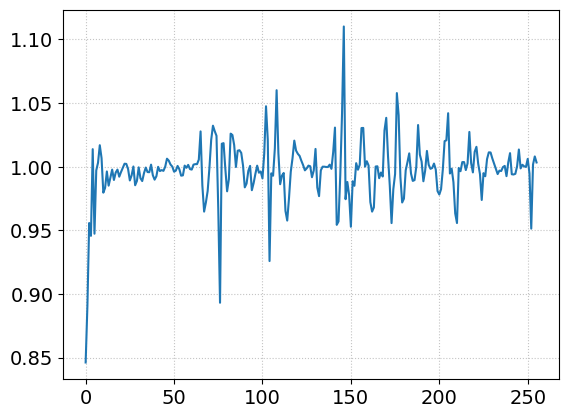

In [30]:
plt.plot((alpha2[1:Q]*(z[2:Q+1]-z[1:Q]) - beta2[1:Q])/(alpha[1:Q]-beta[1:Q]))

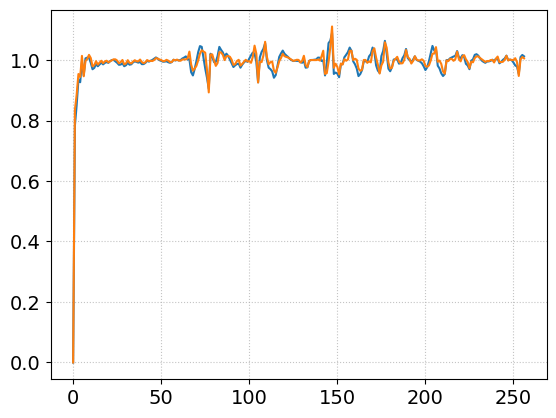

In [31]:
#plt.plot(alpha[:Q])
plt.plot(alpha2[:Q]*(z[2:Q+2]-z[:Q])/2 / alpha[:Q])
plt.plot(alpha2[:Q]*(z[1:Q+1]-z[:Q]) / alpha[:Q])

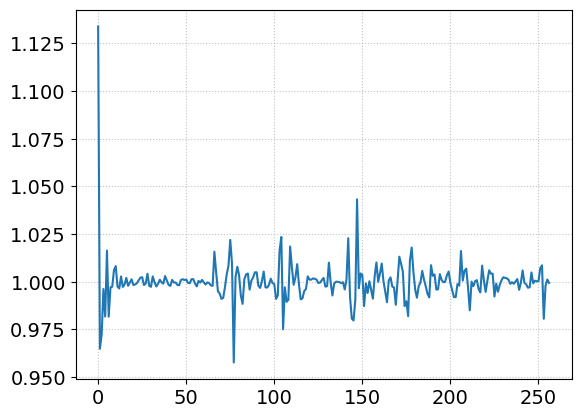

In [32]:
#plt.plot(beta[:Q])
plt.plot(beta2[:Q] / beta[:Q])

In [33]:
gram_to_ppm = 1e18*Dome_C.R*Dome_C.T / (6.022140857e23*Dome_C.pressure*s_open/rho*np.exp(Dome_C.M_air*Dome_C.g*z/(Dome_C.R*Dome_C.T))*1e-6)
gram_to_ppm[teller_co:] = 0

U = (gram_to_ppm * s_open/s)[:Q]
U.shape

/tmp/ipykernel_2543/3586143867.py:1: RuntimeWarning: divide by zero encountered in divide
  gram_to_ppm = 1e18*Dome_C.R*Dome_C.T / (6.022140857e23*Dome_C.pressure*s_open/rho*np.exp(Dome_C.M_air*Dome_C.g*z/(Dome_C.R*Dome_C.T))*1e-6)


(257,)

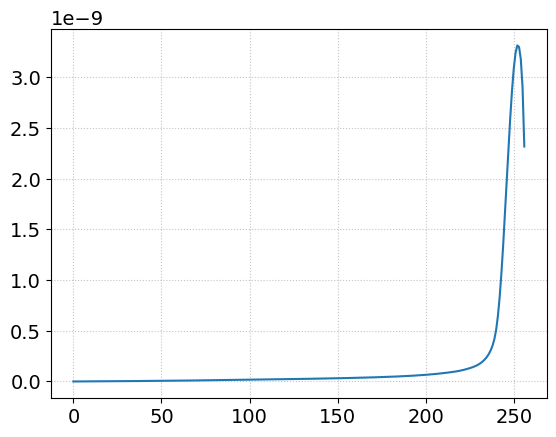

In [34]:
# after ~200 years only ~1-e6 of 14CO is left
# after ~300 years it's ~1e-9
i = int(300/dt1)
plt.plot(np.sum(np.linalg.matrix_power(D,i),axis=-1))

In [35]:
N_D = int(300/dt1) # maximum number of diffusion timesteps worth considering
D_t = np.moveaxis(cum_mat_prod(D,N_D),0,-1)
D_t.shape

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:00<00:00, 340.00it/s]


(257, 257, 30)

In [36]:
# apply our unit conversion ahead of time
# to avoid repetitive multiplication
DU = (np.sum(cum_mat_prod(D1,int(dt1/Dome_C.dt)), axis=0).T @ D_t)*U[None,:,None] * Dome_C.dt/dt1

# sum over t', with funky indexing to account for -t'-t''=diffusion time and p+At''=leak depth
A_open = np.zeros((len(L),Q,Q,len(t1)))

dt2 = dt1
for t2 in tqdm(range(Q)): #t2 = time spent in grains before leaking
    A_open[:,:,:-t2 if t2>0 else None,t2:t2+N_D] += DU[None,:,t2:,len(t1)-t2-1::-1] * (np.exp(-lambd*t2*dt2) * (1-L)**(t2*dt2))[:,None,None,None]
A_open *= (1-(1-L)**dt1)[:,None,None,None] * dt1

delta_pa = interp_mat(a[:,None],p[None,:])
A_open = delta_pa.T[:,:Q] @ A_open
A_open.shape

100%|█████████████████████████████████████████████████████████████████████████████████| 257/257 [00:02<00:00, 95.66it/s]


(2, 257, 256, 1004)

In [37]:
A_open_atm = np.sum(cum_mat_prod(D1,int(dt1/Dome_C.dt)), axis=0)[:,0] @ D_t[:,:,::-1]
A_open_atm.shape

100%|███████████████████████████████████████████████████████████████████████████████| 999/999 [00:00<00:00, 2099.84it/s]


(257, 30)

In [38]:
gas_history = Dome_C.gas_history['C14_CO'][0]*np.ones(len(t1))

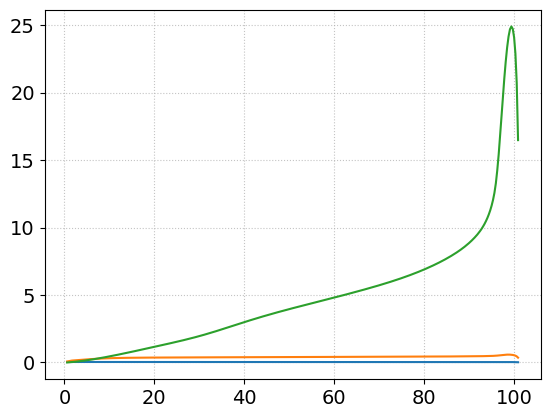

In [39]:
plt.plot(z[:Q], A_open_atm @ gas_history[-N_D:])
plt.plot(z[:Q], (np.sum(A_open, axis=-1) @ P).T)

$$\vec{c}^{closed}_{a,t} = \sum_{t',p} (\vec{R}\cdot[\hat{A}^{closed}\hat{\delta}_{p,a+At'} + \hat{A}^{trap}])_{a,p,t'}(\vec{P}\cdot\vec{f})_p\vec{\phi}_{t+t'} + \sum_{t'}\hat{A}^{atm}_{a,t'}\vec{c}^{atm}_{t+t'}$$

$$\hat{A}^{\text{closed}}_{l,a,t'} = e^{\lambda t'}dt'\hat{\delta}_{a,p-At'}\sum_{t''}^{-t'}\hat{\delta}_{a',p+At''}\frac{s_c(a')}{s(a')}(1-L)^{t''}(1-(1-L)^{dt''})$$

$t''$ - leak time (relative to production)

$$\hat{A}^{trap}_{l,a,p,t'} = U_{ppm\rightarrow g}(a)\sum_{t''}^{-t'}e^{\lambda t''}Tr(a,t'')\hat{A}^{open}_{l,a-At'',p,t'-t''}dt''$$

$$\hat{A}^{atm}_{a,t'} = U_{ppm\rightarrow g}(a)\sum_{t''}e^{-\lambda t''}Tr(a,t'')\hat{A}^{atm}_{a-At'',t'-t''}dt''$$

$t''$ - trapping time (relative to production)

$$Tr(a,t'') = tr(a-At'')/\sum_{t'''} tr(a-At''') dt'''$$

In [40]:
dt2 = dt1
t2 = t1-t1[0]
i = np.arange(len(z)) # assuming p=At'
sc_cast = (s_closed/s)[None,(i[:,None]+i[None,:]).clip(max=i[-1])]*(i[None,:,None]+i[None,None,:]<=i[-1])
A_closed = np.cumsum(
    sc_cast * (1-L[:,None,None])**t2[None,None,:],
    axis=-1
)[:,:,::-1] * (1-(1-L)**dt2)[:,None,None] * np.exp(lambd * t1)[None,None,:] * dt1
A_closed = A_closed[:,(i[:,None]+i[None,::-1]).clip(max=i[-1]),i[None,:]] * (i[:,None]+i[None,::-1]<=i[-1])
#* np.einsum('p+t, lt->lp', s_c/s)
A_closed.shape
#axis0 - Leakage rate (L)
#axis1 - accumulation depth (a)
#axis2 - production time (t1)

(2, 1004, 1004)

In [41]:
ppm_to_gram_cl = (6.022140857e23 * Dome_C.pressure * s_closed / rho * bubble_pres * 1e-6)/(1e18*Dome_C.R*Dome_C.T)

In [42]:
trapping_t = rho*smooth_diff(s_closed*bubble_pres/rho)/dz # Acc*rho_ice/(Acc*rho_ice/rho) = rho
i = np.arange(len(t1))
Trap = trapping_t[(i[:,None]-i[None,:]).clip(min=0)]/np.cumsum(trapping_t*dt1)[:,None] * (i[:,None]>=i[None,:])

In [43]:
A_trap = np.zeros((len(L), len(a), len(p), len(t1)))
dt2 = dt1
for t2 in tqdm(range(len(t1))):
    A_trap[:,t2:t2+Q,:,t2:] += np.exp(-lambd*t2*dt2) * Trap[None,t2:t2+Q,None,None,t2] * A_open[:,:len(a)-t2,:,:-t2 if t2>0 else None] * dt2
A_trap *= ppm_to_gram_cl[None,:,None,None]

100%|███████████████████████████████████████████████████████████████████████████████| 1004/1004 [04:38<00:00,  3.60it/s]


In [50]:
A_trap_atm = np.zeros((len(a), len(t1)))
dt2 = dt1
for t2 in tqdm(range(len(t1))):
    A_trap_atm[t2:t2+Q,t2:t2+N_D] += np.exp(-lambd*t2*dt2) * Trap[t2:t2+Q,None,t2] * A_open_atm[:len(a)-t2,:len(t1)-t2 if t2>0 else None] * dt2
A_trap_atm *= ppm_to_gram_cl[:,None]

100%|████████████████████████████████████████████████████████████████████████████| 1004/1004 [00:00<00:00, 28266.84it/s]


$$\hat{A}_{l,s,p,t'} = \hat{S}_{s,a}\cdot[\hat{A}^{grains}\hat{\delta}_{p,a+At'}+\hat{A}^{closed}\hat{\delta}_{p,a+At'}+\hat{A}^{trap}]_{l,a,p,t'}$$

$$\hat{A}^{atm}_{s,t'} = \hat{S}\cdot \hat{A}^{atm}$$

$$\vec{c}^{pred}_s = \sum_{t',p} (\vec{R}\cdot\hat{A})_{s,p,t'}(\vec{P}\cdot\vec{f})_p\vec{\phi}_{t'} + \sum_{t'}\hat{A}^{atm}_{s,t'}\vec{c}_{t'}^{atm}$$

$$\Sigma^{pred}_{ss'} = (\vec{\phi}\vec{R}\hat{S}\sum \hat{A})_{s,p}(\vec{f}\Sigma^{prod}\vec{f}^T)_{p,p'}(\vec{\phi}\vec{R}\hat{S}\sum \hat{A})^T_{p',s'} + (\hat{S}\hat{A}^{atm})_{s,t}\Sigma^{atm}_{tt'}(\hat{S}\hat{A}^{atm})^T_{t',s'}$$

In [55]:
S_mat = (Prop_DC.h_samp_bins[1,:,None]-a[None,:]).clip(0,da[None,:]) - (Prop_DC.h_samp_bins[0,:,None]-a[None,:]).clip(0,da[None,:])
S_mat /= np.sum(S_mat, axis=-1, keepdims=True)
#axis0 - Sample Depth
#axis1 - Accumulation Depth
S_mat.shape

(10, 1004)

In [58]:
A_profile = (A_grains[:,None,None,:] + A_closed[:,:,None,:])*delta_pahist[None,:,:,:] + A_trap
A_total = np.einsum('sa, lapt->lspt', S_mat, A_profile)
A_total.shape

In [ ]:
A_atm = S_mat @ A_trap_atm
A_atm.shape

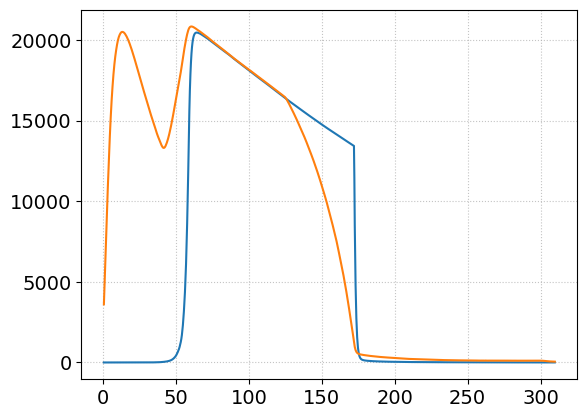

In [62]:
plt.plot(z, (np.sum(A_profile, axis=-1) @ P).T)